In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

C:\Users\hemas\anaconda3\envs\new_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data = pd.read_csv("stock_data.csv")
data.index = data['Date']
data = data.drop('Date', axis = 1)
data

,msft,google,meta,tesla
Date,,,,
19-08-2022,286.149994,118.120003,167.960007,296.666656
22-08-2022,277.750000,115.070000,163.050003,289.913330
23-08-2022,276.440002,114.769997,161.110001,296.453339
24-08-2022,275.790008,114.699997,163.259995,297.096680
25-08-2022,278.850006,117.699997,168.779999,296.070007
...,...,...,...,...
12-12-2025,478.529999,310.519989,644.229981,458.959992
15-12-2025,474.820007,309.320007,647.510010,475.309998
16-12-2025,476.390015,307.730011,657.150024,489.880005


In [3]:
WINDOW_SIZE = 60
TRAIN_SIZE = 597
SCALAR = MinMaxScaler(feature_range=(0, 1))

In [4]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

C:\Users\hemas\anaconda3\envs\new_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def process(df):
    scaled_data = SCALAR.fit_transform(df)

    def create_sequences(data, window_size=60):
        X, y = [], []
        for i in range(window_size, len(data)):
            X.append(data[i-window_size:i, 0])
            y.append(data[i, 0])
        # print(len(X))
        return np.array(X), np.array(y)
    
    X, y = create_sequences(scaled_data, WINDOW_SIZE)

    X_train, X_test = X[:TRAIN_SIZE], X[TRAIN_SIZE:]
    y_train, y_test = y[:TRAIN_SIZE], y[TRAIN_SIZE:]
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

    history = model.fit(
        X_train,
        y_train,
        epochs=25,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )
    
    y_pred_scaled = model.predict(X_test)
    y_pred = SCALAR.inverse_transform(y_pred_scaled)
    y_test_actual = SCALAR.inverse_transform(y_test.reshape(-1, 1))

    # print(len(y_test_actual), len(y_pred))
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    print("RMSE:", rmse)
    return y_pred, y_test_actual

In [22]:
send_data = data[['msft']]
# print(send_data)
pred, actual = process(send_data)

Epoch 1/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0017 - val_loss: 8.2363e-04
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0014 - val_loss: 8.6390e-04
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 5/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0013 - val_loss: 9.6614e-04
Epoch 6/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0014 - val_loss: 9.0729e-04
Epoch 7/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0013 - val_loss: 8.9830e-04
Epoch 9/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0015 - val_loss: 8.0228e-04
Epoch 10/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 11/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0015 - val_loss: 8.1633e-04
Epoch 12/25
17/17 ━━━━━━━━━━━━━━━━━

In [20]:
len(te)

180

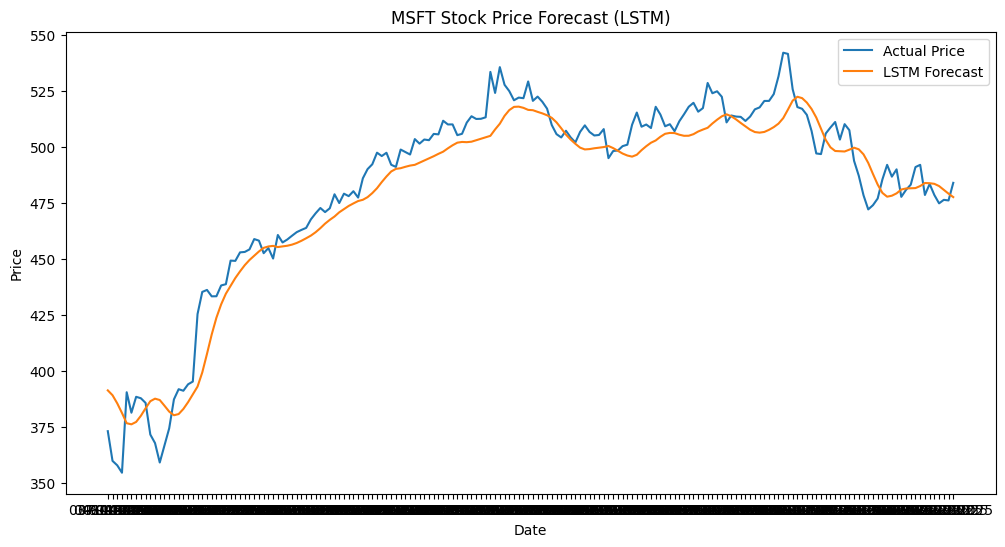

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index[-len(actual):],
    actual,
    label="Actual Price"
)

plt.plot(
    data.index[-len(pred):],
    pred,
    label="LSTM Forecast"
)

plt.title("MSFT Stock Price Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

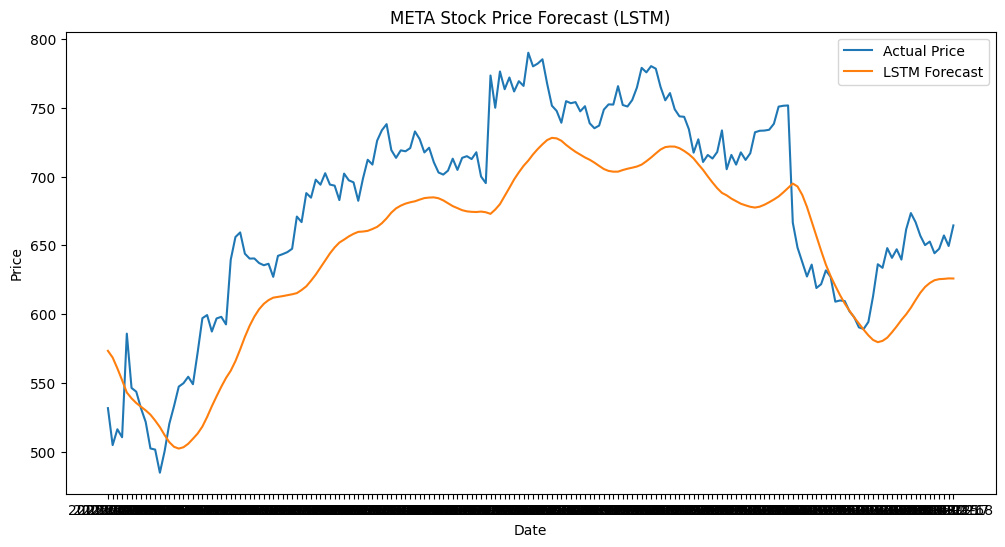

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index[-len(actual):],
    actual,
    label="Actual Price"
)

plt.plot(
    data.index[-len(pred):],
    pred,
    label="LSTM Forecast"
)

plt.title("META Stock Price Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [21]:
msft = pred.copy()

In [18]:
tsla = pred.copy()

In [14]:
# goog = pred.copy()

In [10]:
# meta = pred.copy()
# meta

array([[608.0195 ],
       [603.8858 ],
       [597.34357],
       [589.8861 ],
       [581.8885 ],
       [577.05707],
       [573.031  ],
       [569.67755],
       [566.41547],
       [562.92444],
       [558.6001 ],
       [553.83276],
       [548.24805],
       [542.99536],
       [539.0483 ],
       [536.74646],
       [536.30084],
       [537.2733 ],
       [539.3732 ],
       [541.90936],
       [545.5748 ],
       [550.87244],
       [557.15125],
       [563.3147 ],
       [569.48517],
       [575.4013 ],
       [580.628  ],
       [587.0837 ],
       [594.7885 ],
       [603.16754],
       [610.98914],
       [617.90454],
       [623.857  ],
       [628.7235 ],
       [632.5531 ],
       [635.54407],
       [637.4403 ],
       [639.1456 ],
       [640.7087 ],
       [642.19086],
       [643.66797],
       [646.0539 ],
       [648.7988 ],
       [652.55054],
       [656.68164],
       [661.42426],
       [666.20575],
       [671.1283 ],
       [675.5664 ],
       [679.4279 ],


In [25]:
mst = [goog, meta, tsla, msft]

In [26]:
dfs = pd.DataFrame([goog, meta, tsla, msft], columns = ['GOOGLE', 'META', 'TESLA', 'MSFT'])
dfs

ValueError: Must pass 2-d input. shape=(4, 180, 1)

In [28]:
dfs = pd.DataFrame(
    np.hstack([goog, meta, tsla, msft]),
    columns=['GOOGLE', 'META', 'TESLA', 'MSFT']
)
dfs

,GOOGLE,META,TESLA,MSFT
0,163.119110,608.019470,277.111908,381.115021
1,161.813416,603.885803,274.783142,378.625488
2,160.130539,597.343567,266.970093,373.882874
3,158.394485,589.886108,256.085083,368.509918
4,156.577591,581.888489,243.182297,363.239471
...,...,...,...,...
175,303.559326,652.986877,445.632355,478.435669
176,303.057526,654.428955,445.640472,476.123688
177,302.214172,655.309326,450.925476,473.090302
178,301.121063,656.165405,461.551910,470.711700


In [36]:
take_date = data[data.index >= '2025-04-03']
take_date

,msft,google,meta,tesla
Date,,,,
2025-04-03,373.109985,152.630005,531.619995,267.279999
2025-04-04,359.839996,147.740005,504.730011,239.429993
2025-04-07,357.859985,149.240005,516.250000,233.289993
2025-04-08,354.559998,146.580002,510.450012,221.860001
2025-04-09,390.489990,161.059998,585.770020,272.200012
...,...,...,...,...
2025-12-12,478.529999,310.519989,644.229980,458.959991
2025-12-15,474.820007,309.320007,647.510010,475.309998
2025-12-16,476.390015,307.730011,657.150024,489.880005


In [37]:
dfs.index = take_date.index
dfs

,GOOGLE,META,TESLA,MSFT
Date,,,,
2025-04-03,163.119110,608.019470,277.111908,381.115021
2025-04-04,161.813416,603.885803,274.783142,378.625488
2025-04-07,160.130539,597.343567,266.970093,373.882874
2025-04-08,158.394485,589.886108,256.085083,368.509918
2025-04-09,156.577591,581.888489,243.182297,363.239471
...,...,...,...,...
2025-12-12,303.559326,652.986877,445.632355,478.435669
2025-12-15,303.057526,654.428955,445.640472,476.123688
2025-12-16,302.214172,655.309326,450.925476,473.090302


In [38]:
dfs.to_csv('Apl-Dec2025.csv')

In [10]:
meta_train = model.fit(
    x,
    y,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0543 - val_loss: 0.0188
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0078 - val_loss: 0.0050
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0047 - val_loss: 0.0049
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0028 - val_loss: 0.0045
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0028 - val_loss: 0.0058
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0031 - val_loss: 0.0036
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0027 - val_loss: 0.0032
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 9/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 10/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0024 - val_loss: 0.0032
Epoch 11/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0022 - val_loss: 0.0030
Epoch 12/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0

In [18]:
y_pred_scaled = model.predict(x_test)

# Inverse scale
y_pred = SCALAR.inverse_transform(y_pred_scaled)
y_test_actual = SCALAR.inverse_transform(y_test.reshape(-1, 1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [19]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print("RMSE:", rmse)

RMSE: 29.812292094797304


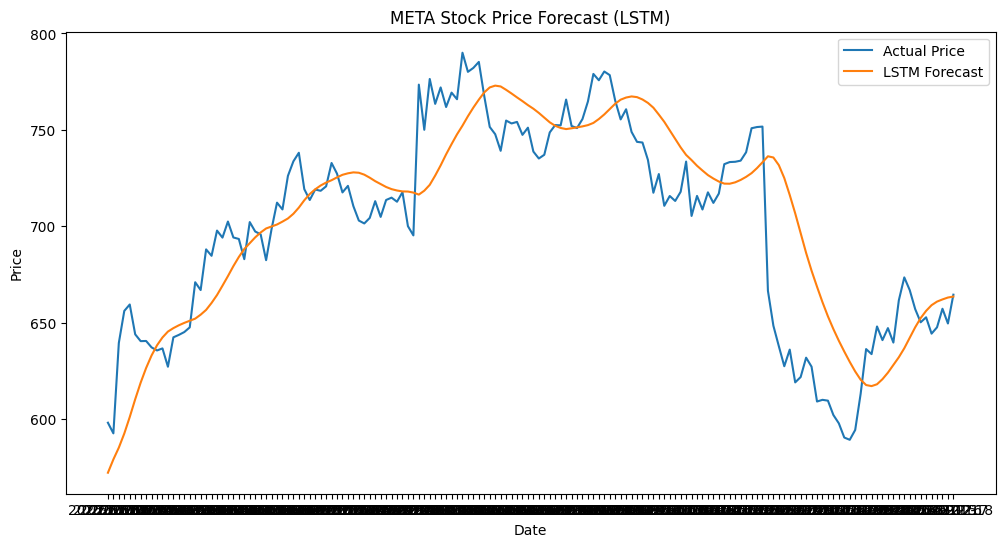

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index[-len(y_test_actual):],
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    df.index[-len(y_pred):],
    y_pred,
    label="LSTM Forecast"
)

plt.title("META Stock Price Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

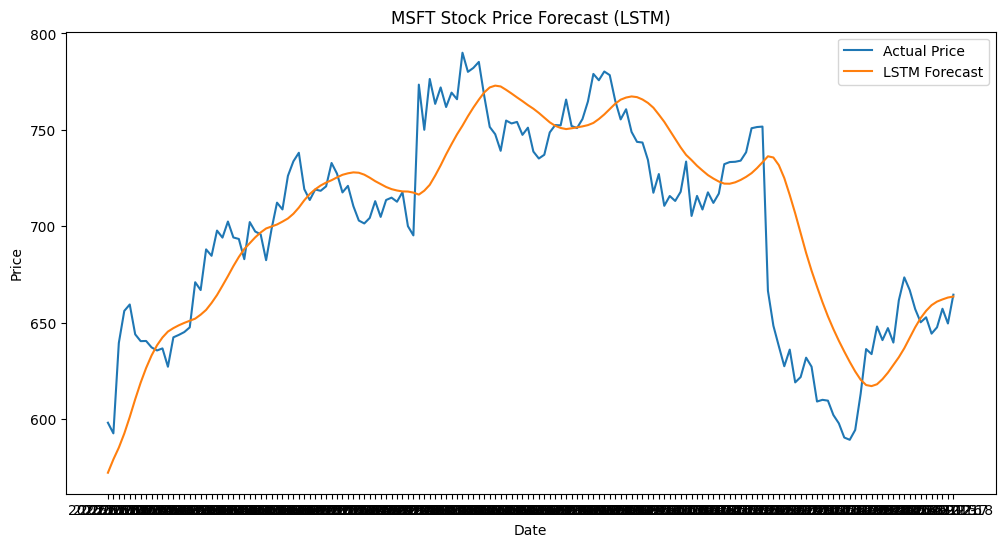

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index[-len(y_test_actual):],
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    df.index[-len(y_pred):],
    y_pred,
    label="LSTM Forecast"
)

plt.title("MSFT Stock Price Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [25]:
y_pred

array([[572.06396],
       [578.9717 ],
       [585.0889 ],
       [592.4059 ],
       [600.9639 ],
       [610.18713],
       [618.7909 ],
       [626.39404],
       [632.9097 ],
       [638.183  ],
       [642.2476 ],
       [645.3062 ],
       [647.09296],
       [648.5704 ],
       [649.8166 ],
       [650.92816],
       [652.0157 ],
       [654.07263],
       [656.55194],
       [660.1638 ],
       [664.26404],
       [669.1052 ],
       [674.0762 ],
       [679.2704 ],
       [684.0026 ],
       [688.1473 ],
       [691.20685],
       [694.1866 ],
       [696.73486],
       [698.80865],
       [699.8666 ],
       [700.8676 ],
       [702.3626 ],
       [703.9925 ],
       [706.421  ],
       [709.62506],
       [713.43164],
       [716.6686 ],
       [719.11426],
       [721.10223],
       [722.6244 ],
       [723.8435 ],
       [725.3155 ],
       [726.6523 ],
       [727.42426],
       [727.9155 ],
       [727.71844],
       [726.7273 ],
       [725.15424],
       [723.3638 ],
